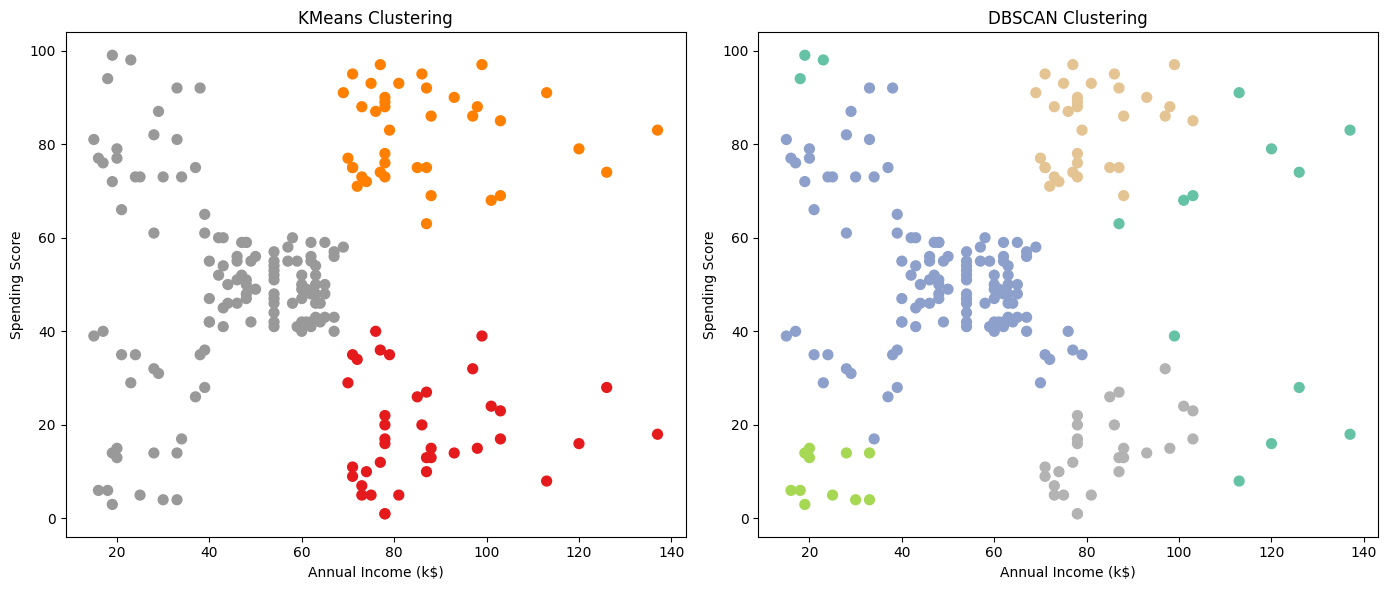

KMeans cluster counts:
 0     38
1     39
2    123
Name: count, dtype: int64
DBSCAN cluster counts (including noise -1):
 -1     15
 0    115
 1     11
 2     32
 3     27
Name: count, dtype: int64


'Output -\nKMeans cluster counts:\n0    81\n1    39\n2    22\n3    35\n4    23\nName: count, dtype: int64\nDBSCAN cluster counts (including noise -1):\n-1      8\n0    157\n1     35\nName: count, dtype: int64\n'

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
# ​​​ Load dataset from reliable raw URL
url = "https://gist.githubusercontent.com/ryanorsinger/cc276eea59e8295204d1f581c8da509f/raw/mall_customers.csv"
df = pd.read_csv(url)
# ​​​ Select features: Annual Income and Spending Score
X = df[['annual_income', 'spending_score']].values
# ​​​ Scale features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# ​​​ KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
# ​​​ DBSCAN clustering
dbscan = DBSCAN(eps=.4, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
# ​​​ Visualization
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
# KMeans plot
axs[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='Set1', s=50)
axs[0].set_title("KMeans Clustering")
axs[0].set_xlabel("Annual Income (k$)")
axs[0].set_ylabel("Spending Score")
# DBSCAN plot
axs[1].scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='Set2', s=50)
axs[1].set_title("DBSCAN Clustering")
axs[1].set_xlabel("Annual Income (k$)")
axs[1].set_ylabel("Spending Score")
plt.tight_layout()
plt.show()
# ​​​ Output clusters summary
print("KMeans cluster counts:\n", pd.Series(kmeans_labels).value_counts().sort_index())
print("DBSCAN cluster counts (including noise -1):\n", pd.Series(dbscan_labels).value_counts().sort_index())
'''Output -
KMeans cluster counts:
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
DBSCAN cluster counts (including noise -1):
-1      8
0    157
1     35
Name: count, dtype: int64
'''